In [ ]:
import pandas as pd
import re

import seaborn as sns
from wordcloud import WordCloud
import matplotlib.pyplot as plt

import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from collections import Counter

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import SVC

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
df =pd.read_csv(r'IGS.csv')
df.head()

,review_description,rating,sentiment
0,Instagram is the best of all the social media....,5,positive
1,The only complaint i have is about the video c...,4,positive
2,"Easy to use for the most part, good to talk to...",4,positive
3,Updating my review since many of the issues ha...,4,positive
4,So editing my review because there is a huge b...,4,positive


In [ ]:
df.shape

(50000, 3)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   review_description  50000 non-null  object
 1   rating              50000 non-null  int64 
 2   sentiment           50000 non-null  object
dtypes: int64(1), object(2)
memory usage: 1.1+ MB


In [ ]:
df.isnull().sum()

review_description    0
rating                0
sentiment             0
dtype: int64

In [ ]:
df.duplicated().sum()

0

In [ ]:
df = df.drop('rating', axis = 1)
df

,review_description,sentiment
0,Instagram is the best of all the social media....,positive
1,The only complaint i have is about the video c...,positive
2,"Easy to use for the most part, good to talk to...",positive
3,Updating my review since many of the issues ha...,positive
4,So editing my review because there is a huge b...,positive
...,...,...
49995,So nice awsome i love insta we have to post st...,positive
49996,The best social media platform or a thing but ...,positive
49997,Its nice But there is a issue I think it shoul...,positive
49998,"DM isn't working properly, if I type anything ...",negative


In [ ]:
sentiment_counts = df['sentiment'].value_counts()
print(sentiment_counts)

positive    25000
negative    25000
Name: sentiment, dtype: int64


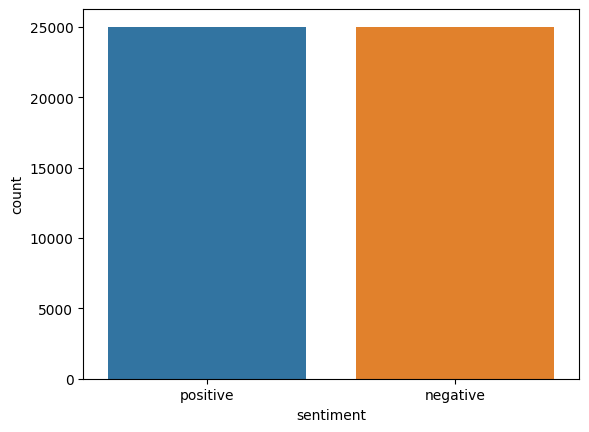

In [ ]:
ax = sns.countplot(x='sentiment', data=df)

In [ ]:
def remove_tags(string):
    # Remove URLs
    result = re.sub(r'https?://\S+', '', string)

    # Remove non-alphanumeric characters and commas
    result = re.sub(r'[^\w\s]', '', result)

    # Convert to lowercase
    result = result.lower()

    return result

df['review_description'] = df['review_description'].apply(lambda cw: remove_tags(cw))
df

,review_description,sentiment
0,instagram is the best of all the social media ...,positive
1,the only complaint i have is about the video c...,positive
2,easy to use for the most part good to talk to ...,positive
3,updating my review since many of the issues ha...,positive
4,so editing my review because there is a huge b...,positive
...,...,...
49995,so nice awsome i love insta we have to post st...,positive
49996,the best social media platform or a thing but ...,positive
49997,its nice but there is a issue i think it shoul...,positive
49998,dm isnt working properly if i type anything al...,negative


In [ ]:
def stem_text(text):
    # Tokenize the text into words
    words = word_tokenize(str(text))  # Convert to string

    # Initialize the Porter Stemmer
    porter = PorterStemmer()

    # Apply stemming to each word
    stemmed_words = [porter.stem(word) for word in words]

    # Join the stemmed words back into a single string
    stemmed_text = " ".join(stemmed_words)

    return stemmed_text

df['review_description'] = df['review_description'].apply(stem_text)
df

,review_description,sentiment
0,instagram is the best of all the social media ...,positive
1,the onli complaint i have is about the video c...,positive
2,easi to use for the most part good to talk to ...,positive
3,updat my review sinc mani of the issu have bee...,positive
4,so edit my review becaus there is a huge bug i...,positive
...,...,...
49995,so nice awsom i love insta we have to post sto...,positive
49996,the best social media platform or a thing but ...,positive
49997,it nice but there is a issu i think it should ...,positive
49998,dm isnt work properli if i type anyth all the ...,negative


In [ ]:
def tokenize_text(text):
    # Tokenize the text into words
    words = word_tokenize(str(text))  # Convert to string
    return words

df['review_description'] = df['review_description'].apply(tokenize_text)
df

,review_description,sentiment
0,"[instagram, is, the, best, of, all, the, socia...",positive
1,"[the, onli, complaint, i, have, is, about, the...",positive
2,"[easi, to, use, for, the, most, part, good, to...",positive
3,"[updat, my, review, sinc, mani, of, the, issu,...",positive
4,"[so, edit, my, review, becaus, there, is, a, h...",positive
...,...,...
49995,"[so, nice, awsom, i, love, insta, we, have, to...",positive
49996,"[the, best, social, media, platform, or, a, th...",positive
49997,"[it, nice, but, there, is, a, issu, i, think, ...",positive
49998,"[dm, isnt, work, properli, if, i, type, anyth,...",negative


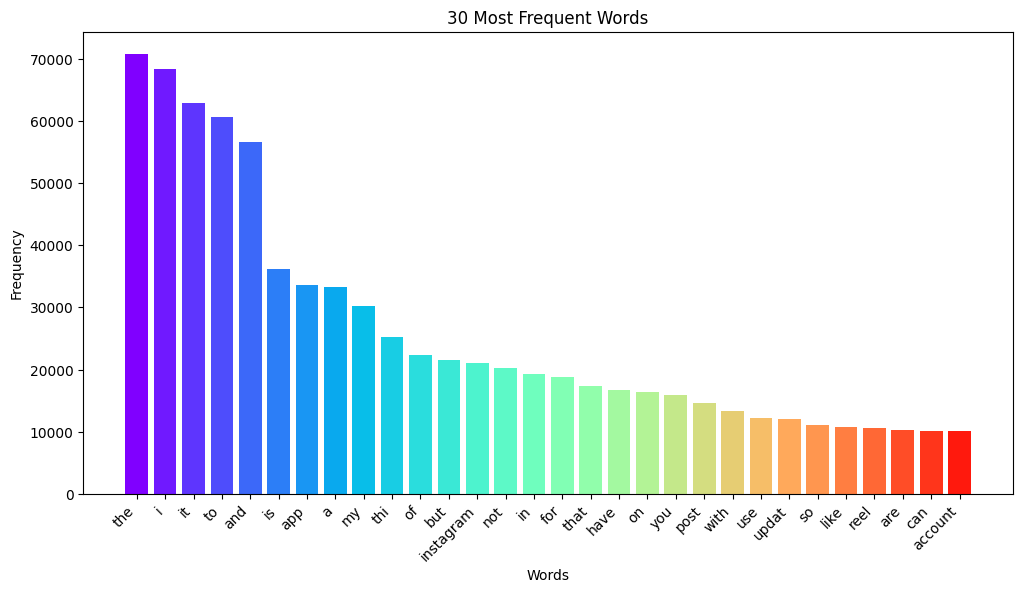

In [ ]:
all_tokens = [word for tokens in df['review_description'] for word in tokens]

# Calculate word frequencies using Counter
word_freq = Counter(all_tokens)

# Get the 30 most frequent words
top_words = word_freq.most_common(30)

# Extract words and their frequencies for plotting
words, frequencies = zip(*top_words)

# Plotting bar chart
plt.figure(figsize=(12, 6))
plt.bar(words, frequencies, color=plt.cm.rainbow([i/30 for i in range(30)]))
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('30 Most Frequent Words')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.show()

In [ ]:
custom_stopwords = ['the', 'i', 'it', 'to', 'and', 'is', 'a', 'my', 'of', 'but', 'not', 'in', 'for', 'that',
                    'have', 'on', 'you', 'with', 'use',' so', 'are', 'can', 'thi', 'cant', 'one', 'im',
                    'app', 'instagram', 'peopl', 'ha', 'wa', 'get', 'veri', 'dont', 'even'
                    ]
stop_words = set(stopwords.words("english"))
stop_words.update([word.lower() for word in custom_stopwords])
df['review_description'] = df['review_description'].apply(lambda tokens: [word for word in tokens if word.lower() not in stop_words])
df

,review_description,sentiment
0,"[best, social, media, ig, post, platform, faci...",positive
1,"[onli, complaint, video, call, featur, small, ...",positive
2,"[easi, part, good, talk, friend, ive, issu, go...",positive
3,"[updat, review, sinc, mani, issu, fix, save, m...",positive
4,"[edit, review, becaus, huge, bug, dislik, actu...",positive
...,...,...
49995,"[nice, awsom, love, insta, post, storystatus, ...",positive
49996,"[best, social, media, platform, thing, locat, ...",positive
49997,"[nice, issu, think, contain, featur, privaci, ...",positive
49998,"[dm, isnt, work, properli, type, anyth, button...",negative


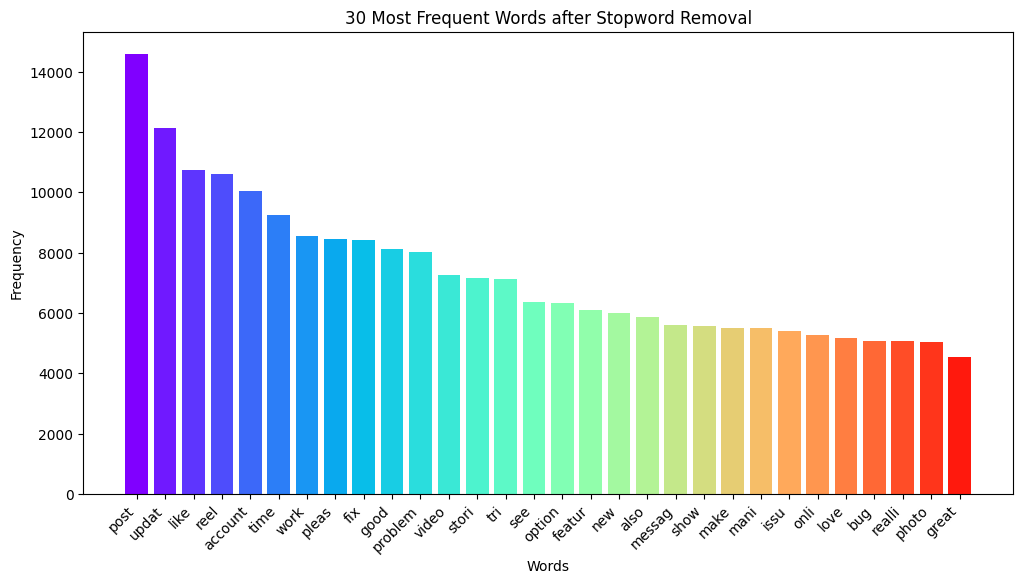

In [ ]:
# Combine all tokenized words into a single list after stopword removal
all_tokens_after_stopwords = [word for tokens in df['review_description'] for word in tokens]

# Calculate word frequencies using Counter
word_freq_after_stopwords = Counter(all_tokens_after_stopwords)

# Get the 30 most frequent words after stopword removal
top_words_after_stopwords = word_freq_after_stopwords.most_common(30)

# Extract words and their frequencies for plotting
words_after_stopwords, frequencies_after_stopwords = zip(*top_words_after_stopwords)

# Plotting bar chart
plt.figure(figsize=(12, 6))
plt.bar(words_after_stopwords, frequencies_after_stopwords, color=plt.cm.rainbow([i/30 for i in range(30)]))
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('30 Most Frequent Words after Stopword Removal')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.show()

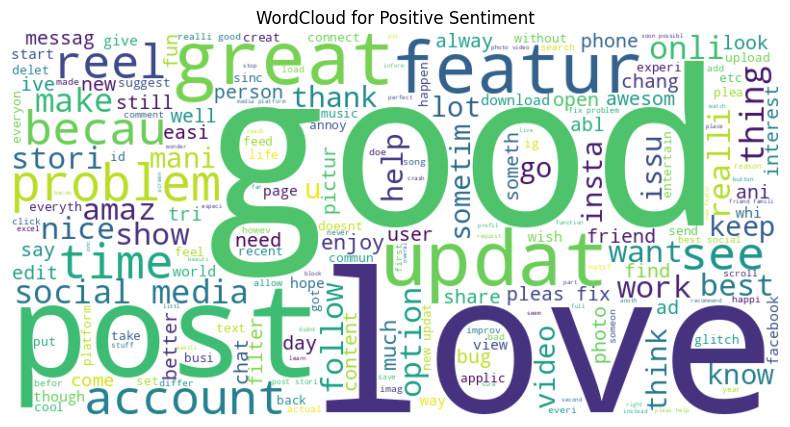

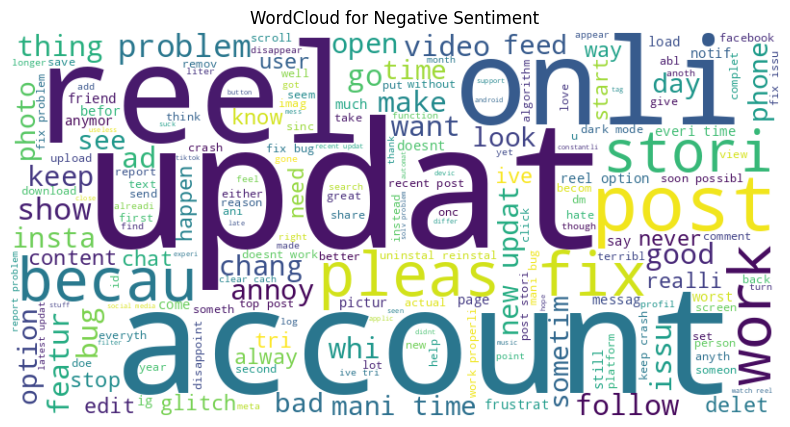

In [ ]:
# Combine all words in string based on sentiment
def combine_words(sentiment):
    return ' '.join([' '.join(tokens) for tokens in df[df['sentiment'] == sentiment]['review_description']])

# Word cloud for positive sentiment
positive_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(combine_words('positive'))
plt.figure(figsize=(10, 5))
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.title('WordCloud for Positive Sentiment')
plt.axis('off')
plt.show()

# Word cloud for negative sentiment
negative_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(combine_words('negative'))
plt.figure(figsize=(10, 5))
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.title('WordCloud for Negative Sentiment')
plt.axis('off')
plt.show()

In [ ]:
X = df["review_description"]
y = df["sentiment"]

from sklearn.model_selection import train_test_split
Xtrain, Xvalid, ytrain, yvalid = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Assuming Xtrain is a list of sentences
documents_train = [' '.join(tokens) for tokens in Xtrain]
documents_valid = [' '.join(tokens) for tokens in Xvalid]

# Create the TfidfVectorizer
tfidf = TfidfVectorizer(stop_words="english")

# Fit the vectorizer on the joined sentences
tfidf.fit(documents_train)

# Transform the training and validation data
X_train_tfidf = tfidf.transform(documents_train)
X_valid_tfidf = tfidf.transform(documents_valid)

# linear

In [ ]:
model = SVC(kernel='linear')
model.fit(X_train_tfidf, ytrain)
# Predicting output for test data
pred = model.predict(X_valid_tfidf)

In [ ]:
accuracy_score(yvalid, pred)

0.8356

In [ ]:
cm = confusion_matrix(yvalid, pred)
cm

array([[4397,  582],
       [1062, 3959]])

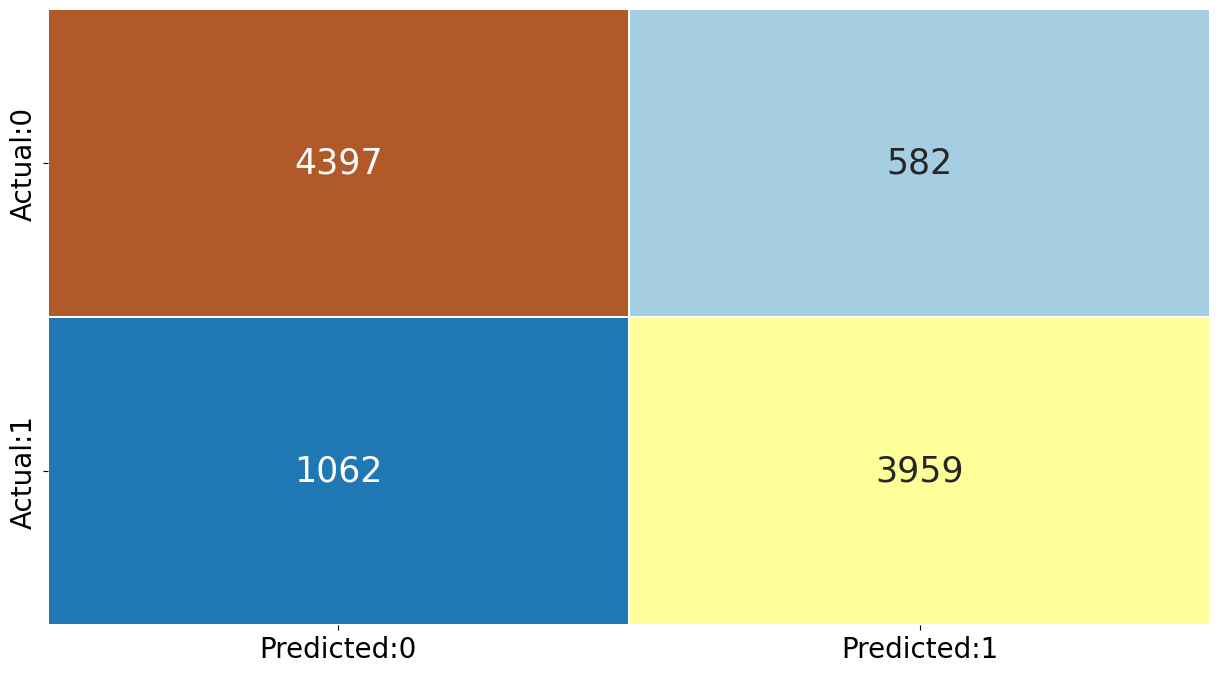

In [ ]:
plt.rcParams['figure.figsize'] = [15,8]
# Confusion matrix to DataFrame
conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1',], index = ['Actual:0','Actual:1',])

# Plotting the confusion matrix
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = 'Paired', cbar = False,linewidths = 0.1, annot_kws = {'size':25})
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

In [ ]:
print(classification_report(yvalid,pred))

              precision    recall  f1-score   support

    negative       0.81      0.88      0.84      4979
    positive       0.87      0.79      0.83      5021

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



# rbf

In [ ]:
model = SVC(kernel='rbf')
model.fit(X_train_tfidf, ytrain)
# Predicting output for test data
pred = model.predict(X_valid_tfidf)

In [ ]:
accuracy_score(yvalid,pred)

0.8408

In [ ]:
cm = confusion_matrix(yvalid, pred)
cm

array([[4433,  546],
       [1046, 3975]])

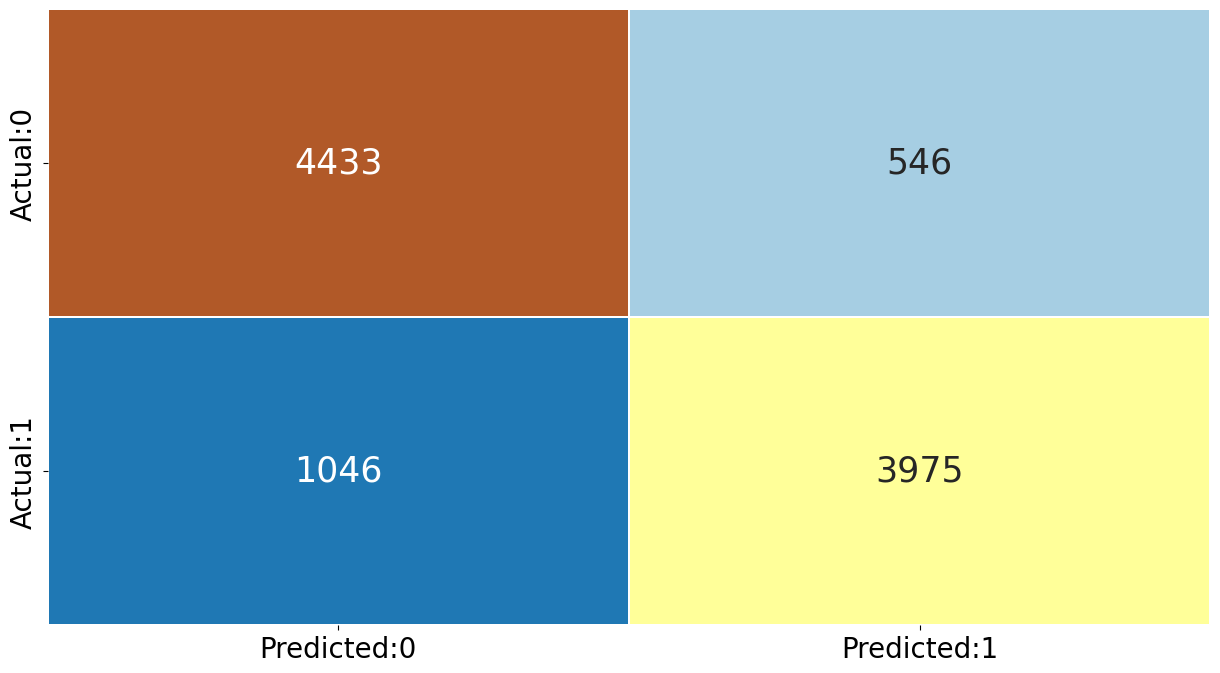

In [ ]:
plt.rcParams['figure.figsize'] = [15,8]
# Confusion matrix to DataFrame
conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1',], index = ['Actual:0','Actual:1',])

# Plotting the confusion matrix
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = 'Paired', cbar = False,linewidths = 0.1, annot_kws = {'size':25})
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

In [ ]:
print(classification_report(yvalid,pred))

              precision    recall  f1-score   support

    negative       0.81      0.89      0.85      4979
    positive       0.88      0.79      0.83      5021

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000



# polynomial

In [ ]:
model = SVC(kernel='poly')
model.fit(X_train_tfidf, ytrain)
# Predicting output for test data
pred = model.predict(X_valid_tfidf)

In [ ]:
accuracy_score(yvalid,pred)

0.8261

In [ ]:
cm = confusion_matrix(yvalid, pred)
cm

array([[4335,  644],
       [1095, 3926]])

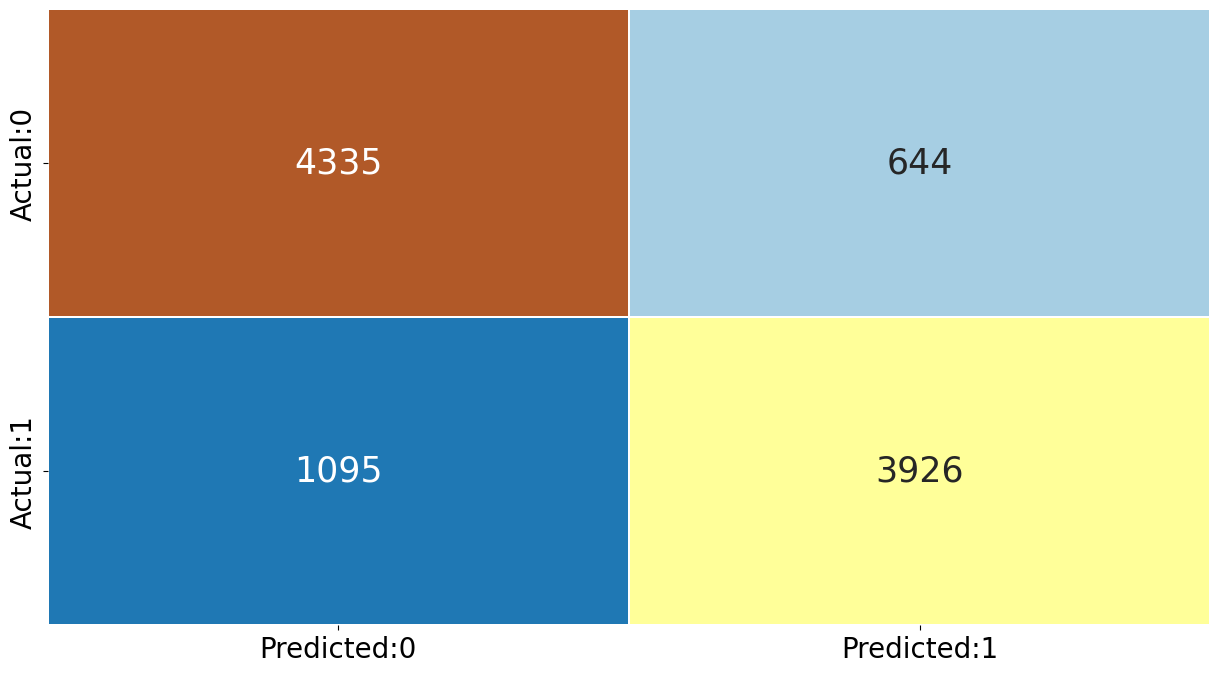

In [ ]:
plt.rcParams['figure.figsize'] = [15,8]
# Confusion matrix to DataFrame
conf_matrix = pd.DataFrame(data = cm,columns = ['Predicted:0','Predicted:1',], index = ['Actual:0','Actual:1',])

# Plotting the confusion matrix
sns.heatmap(conf_matrix, annot = True, fmt = 'd', cmap = 'Paired', cbar = False,linewidths = 0.1, annot_kws = {'size':25})
plt.xticks(fontsize = 20)
plt.yticks(fontsize = 20)
plt.show()

In [ ]:
print(classification_report(yvalid,pred))

              precision    recall  f1-score   support

    negative       0.80      0.87      0.83      4979
    positive       0.86      0.78      0.82      5021

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000

